<div align="right">
АС-23-05, Тищенко Кирилл, Вариант №8
</div>

# Лабораторная работа №1 "Прямые методы одномерной минимизации"

$$f(x) = e^x - \frac{1}{3}x^3 + 2x \to \min, \quad x \in [-2,5, -1].$$

Импортируем необходимые библиотеки

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar

In [15]:
def f(x):
    return np.exp(x) - (1/3)*(x**3) + 2*x

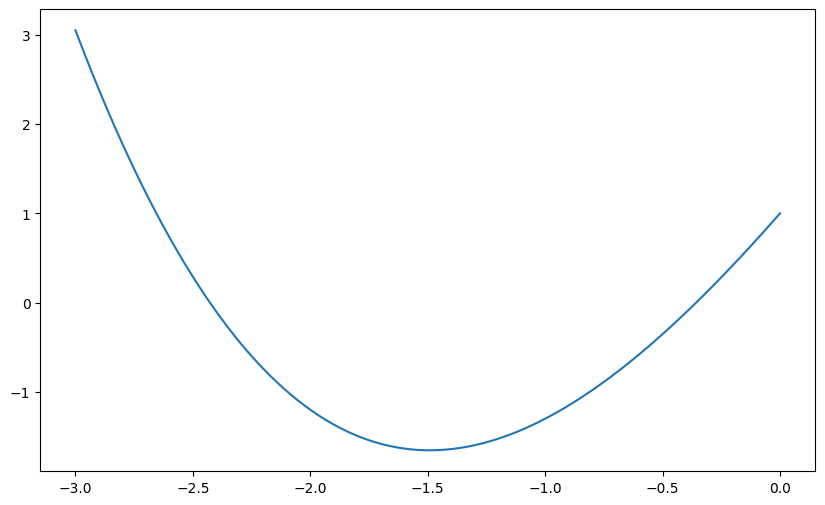

In [136]:
x = np.linspace(-3, 0, 400)
y = f(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

## 2. Находим локальный миминум функции при помощи метода `bounded`, встроенного в библиотеку `scipy`

In [42]:
res = minimize_scalar(f, bounds=(-2.5, -1), method='bounded')
x_min_scipy = res.x
y_min_scipy = f(x_min_scipy)

print(f"Точка минимума x: {x_min_scipy:.6f}")
print(f"Минимальное значение f(x): {y_min_scipy:.6f}")

Точка минимума x: -1.491644
Минимальное значение f(x): -1.651982


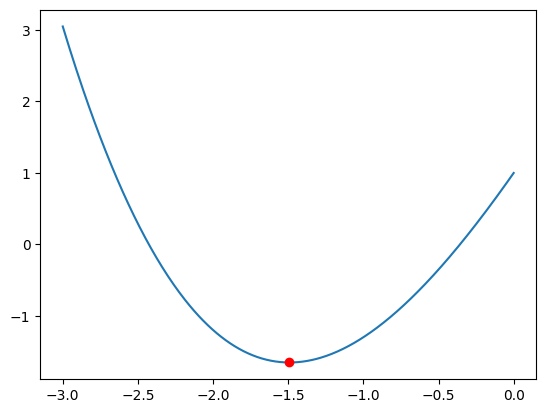

In [114]:
plt.scatter(x_min_scipy, y_min_scipy, color='red', zorder=5)
plt.plot(x, y)

## 3. Находим локальный миминум функции при помощи методов, указанных в задании

### 3.1 Метод поразрядного поиска p = 3, q = 3

In [1]:
def bitwise_search_history(f, a, b, p=4, q=4, eps=1e-6):
    x_curr = a
    delta = (b - a) / p
    f_curr = f(x_curr)
    history_x = [x_curr]
    history_f = [f_curr]
    while abs(delta) > eps:
        x_next = x_curr + delta
        if a <= x_next <= b and f(x_next) < f_curr:
            x_curr = x_next
            f_curr = f(x_curr)
        else:
            delta = -delta / q
        history_x.append(x_curr)
        history_f.append(f_curr)
            
    return history_x, history_f

In [149]:
x_steps, f_steps = bitwise_search_history(f, -2.5, -1)
x_min_bit = x_steps[-1]
f_min_bit = f_steps[-1]
print(f"Поразрядный поиск p=10, q=10: x = {x_min_bit:.6f}, f(x) = {y_min_bit:.6f}")
print(f"Количество итераций: {len(x_steps)}")

Поразрядный поиск p=10, q=10: x = -1.491645, f(x) = -1.651982
Количество итераций: 23


In [157]:
def draw_bin(x_steps, f_steps, f, a, b):
    x_steps_10 = x_steps[:11]
    f_steps_10 = f_steps[:11]
    
    plt.figure(figsize=(10, 6))
    a, b = -2.5, -1
    x_range = np.linspace(a - 0.1, b + 0.1, 500)
    
    plt.plot(x_range, f(x_range), color='blue', alpha=0.4)
    
    plt.plot(x_steps_10[:10], f_steps_10[:10], 'o--', color='grey', markersize=4, alpha=0.8)
    plt.plot(x_steps_10[9:11], f_steps_10[9:11], '--', color='grey', alpha=0.8)
    
    plt.plot(x_steps_10[10], f_steps_10[10], 'ro', markersize=8)
    
    plt.title("Визуализация метода поразрядного поиска на примере первых 10-и итераций")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True, alpha=0.3)
    plt.show()

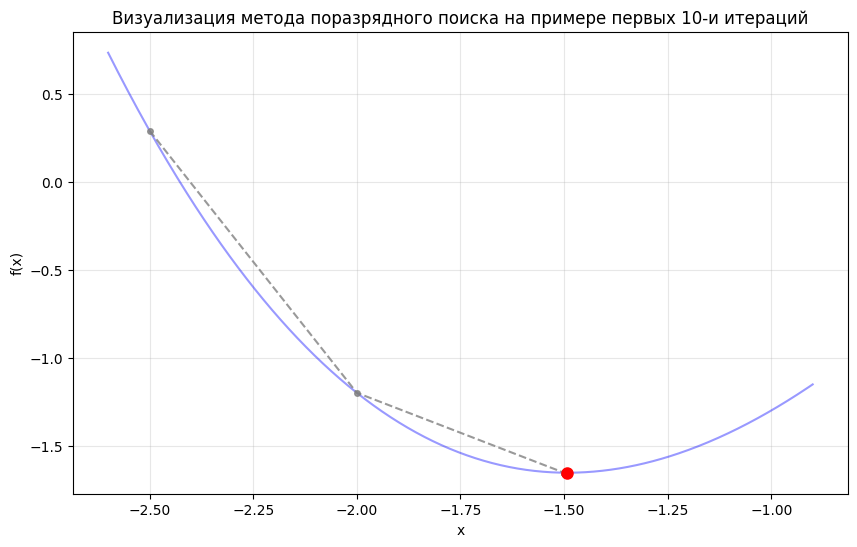

In [158]:
draw_bin(x_steps, f_steps, f, -2.5, -1)

### 3.2 Метод золотого сечения

In [13]:
def golden_ratio(f, a, b, eps=1e-6):
    phi = (1 + 5**0.5) / 2
    res_phi = 2 - phi
    history = []
    x1 = a + res_phi * (b - a)
    x2 = b - res_phi * (b - a)
    f1, f2 = f(x1), f(x2)
    
    while (b - a) > eps:
        history.append((a, b, x1, x2))
        if f1 < f2:
            b = x2
            x2, f2 = x1, f1
            x1 = a + res_phi * (b - a)
            f1 = f(x1)
        else:
            a = x1
            x1, f1 = x2, f2
            x2 = b - res_phi * (b - a)
            f2 = f(x2)
            history.append((a, b, x1, x2))
    return history

In [103]:
history = golden_ratio(f, -2.5, -1, eps=1e-6)

a_fin, b_fin, _, _ = history[-1]
x_min_gr = (a_fin + b_fin) / 2
y_min_gr = f(x_min)

print(f"Метод золотого сечения: x = {x_min_gr:.6f}, f(x) = {y_min_gr:.6f}")
print(f"Количество итераций: {len(history)}")

Метод золотого сечения: x = -1.491644, f(x) = -1.651982
Количество итераций: 45


In [159]:
def draw_gr(f):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_range, y_range, 'b', alpha=0.3, label='f(x)')
    ax.set_title("Визуализация метода золотого сечения на примере первых 10-и итераций")
    
    phi = (1 + 5**0.5) / 2
    a_g, b_g = a, b
    
    for i in range(10):
        x1 = b_g - (b_g - a_g) / phi
        x2 = a_g + (b_g - a_g) / phi
        current_color = 'green' if i < 9 else 'red'
        current_alpha = 0.15 if i < 9 else 0.4
        ax.axvspan(a_g, b_g, color=current_color, alpha=current_alpha)  
        ax.vlines([x1, x2], f(x1)-0.2, f(x1)+0.2, colors=current_color, 
                  linestyles='dotted', alpha=0.7)
        if f(x1) < f(x2):
            b_g = x2
        else:
            a_g = x1
    x_final = (a_g + b_g) / 2
    ax.plot(x_final, f(x_final), 'ro', markersize=8)
    
    ax.grid(True, alpha=0.2)
    plt.show()

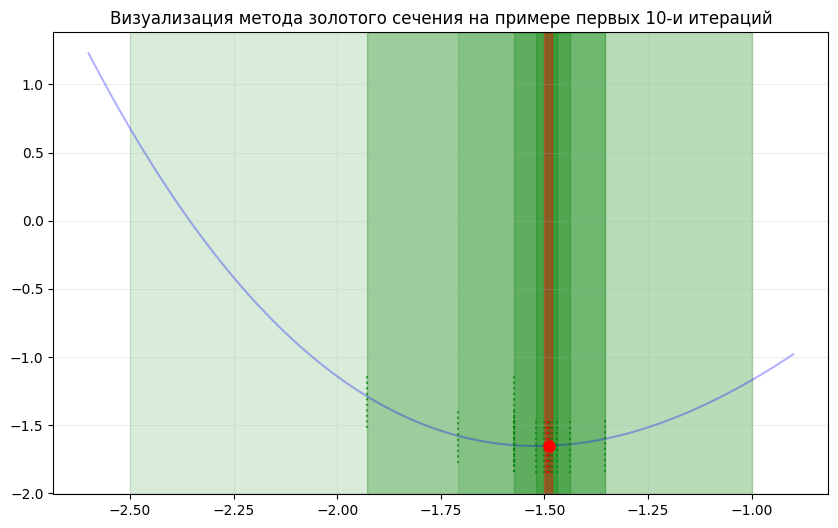

In [160]:
draw_gr(f)

### 3.3 Метод ломанных

In [13]:
def broken_line_method(f, a, b, eps, L):
    x_pts = [a, b]
    f_pts = [f(a), f(b)]
    iterations = 0

    while True:
        iterations += 1
        p_min = float("inf")
        x_new = None
        for i in range(len(x_pts) - 1):
            x_i, x_j = x_pts[i], x_pts[i + 1]
            f_i, f_j = f_pts[i], f_pts[i + 1]
            p_x = (f_i - f_j + L * (x_i + x_j)) / (2 * L)
            p_f = (f_i + f_j + L * (x_i - x_j)) / 2
            if p_f < p_min:
                p_min = p_f
                x_new = p_x
        f_new = f(x_new)
        if abs(f_new - p_min) < eps:
            idx = np.searchsorted(x_pts, x_new)
            x_pts.insert(idx, x_new)
            f_pts.insert(idx, f_new)
            break
        idx = np.searchsorted(x_pts, x_new)
        x_pts.insert(idx, x_new)
        f_pts.insert(idx, f_new)
        
    best_idx = np.argmin(f_pts)

    return x_pts[best_idx], f_pts[best_idx], iterations

In [17]:
L_const = [4.2, 4.3, 4.5, 4.6, 4.8]
for l in L_const:
    x_min_bl, y_min_bl, iterations = broken_line_method(f, -2.5, -1, 10e-6, l)
    print(f"L = {l}")
    print(f"Метод ломаных:     x = {x_min_bl:.6f}, f(x) = {y_min_bl:.6f}")
    print(f"Количество итераций: {iterations}")

L = 4.2
Метод ломаных:     x = -1.491644, f(x) = -1.651982
Количество итераций: 2610
L = 4.3
Метод ломаных:     x = -1.491645, f(x) = -1.651982
Количество итераций: 2616
L = 4.5
Метод ломаных:     x = -1.491644, f(x) = -1.651982
Количество итераций: 2626
L = 4.6
Метод ломаных:     x = -1.491645, f(x) = -1.651982
Количество итераций: 2646
L = 4.8
Метод ломаных:     x = -1.491645, f(x) = -1.651982
Количество итераций: 2672


In [163]:
def draw_bl(history, f, L=4.2):
    history = history[:11]
    
    x_range = np.linspace(-2.5 - 0.1, -1 + 0.1, 500)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_range, f(x_range), 'b', alpha=0.3)
    
    for idx, (hx, hf) in enumerate(history):
        current_color = 'green' if idx < 10 else 'red'
        current_alpha = 0.4 if idx < 10 else 0.8
        
        for j in range(len(hx) - 1):
            x_l, x_r = hx[j], hx[j+1]
            f_l, f_r = hf[j], hf[j+1]
            px = (f_l - f_r + L * (x_l + x_r)) / (2 * L)
            pf = (f_l + f_r + L * (x_l - x_r)) / 2
            ax.plot([x_l, px, x_r], [f_l, pf, f_r], color=current_color, alpha=current_alpha, linewidth=1)
    
    ax.plot(x_min_bl, y_min_bl, 'ro', markersize=8)
    ax.set_title("Визуализация метода ломанных на примере первых 10-и итераций")
    ax.grid(True, alpha=0.2)
    plt.show()

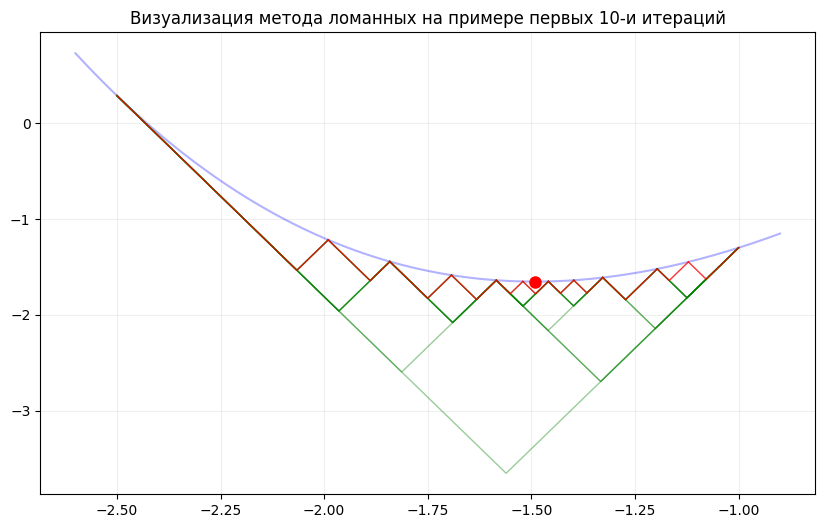

In [164]:
draw_bl(history, f)

| Метод | x_min| f(x_min) | Кол-во итераций |
| :--- | :--- | :--- | :--- |
| Пакетный scipy | -1.491644 | -1.651982 | - |
| Поразрядного поиска | -1.491645 | -1.651982 | 23 (p = q = 4)|
| Золотого сечения | -1.491644 | -1.651982 | 45 |
| Ломанных | -1.491644 | -1.651982 | 2610 (L = 4.2) |

## 5. Находим минимум пологой функции

$$f(x) = e^x - 1 - x - \frac{x^2}{2} - \frac{x^3}{6}$$

In [3]:
def f_teylor(x):
    return np.exp(x) - 1 - x - (x**2)/2 - (x**3)/6

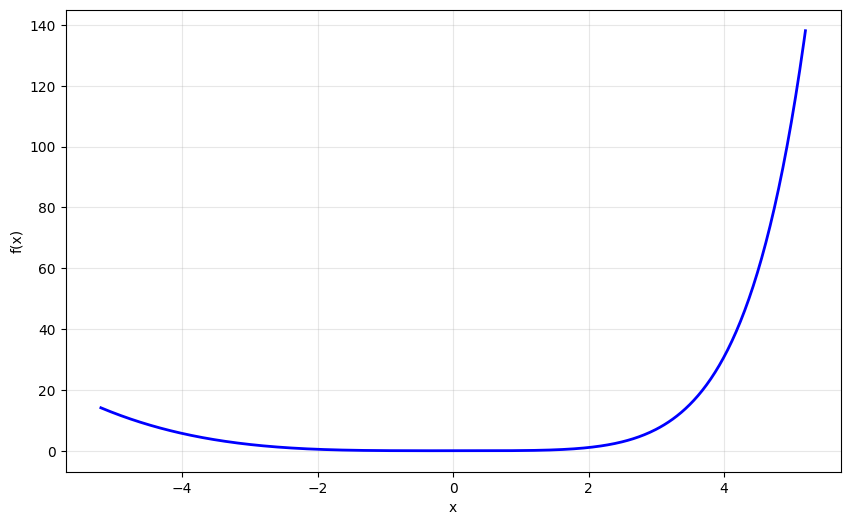

In [6]:
x = np.linspace(-5.2, 5.2, 500)
y = f_teylor(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='blue', linewidth=2)

plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)


plt.show()

In [7]:
res = minimize_scalar(f_teylor, bounds=(-5, 5), method='bounded')
x_min_scipy_teylor = res.x
y_min_scipy_teylor = f_teylor(x_min_scipy_teylor)

print(f"Точка минимума x: {x_min_scipy_teylor:.6f}")
print(f"Минимальное значение f(x): {y_min_scipy_teylor:.6f}")

Точка минимума x: -0.000028
Минимальное значение f(x): -0.000000


### 5.1 Метод поразряжного поиска

In [15]:
x_steps, f_steps = bitwise_search_history(f_teylor, -5, 5, p=5, q=5, eps=1e-4)
x_min_bit = x_steps[-1]
y_min_bit = f_steps[-1]
print(f"Поразрядный поиск: x = {x_min_bit:.6f}, f(x) = {y_min_bit:.6f}")
print(f"Количество итераций: {len(x_steps)}")

Поразрядный поиск: x = -0.000064, f(x) = 0.000000
Количество итераций: 46


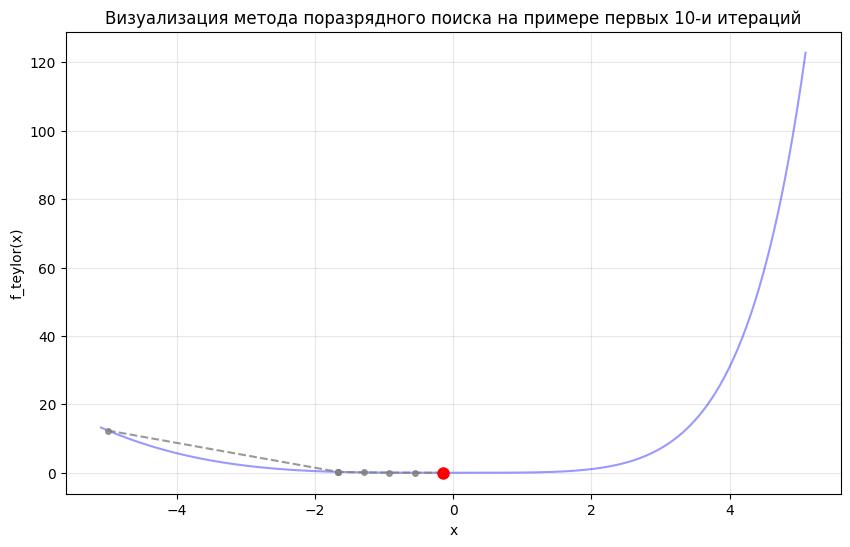

In [22]:
x_steps_10 = x_steps[:11]
f_steps_10 = f_steps[:11]

plt.figure(figsize=(10, 6))
a, b = -2.5, -1
x_range = np.linspace(-5 - 0.1, 5 + 0.1, 500)

plt.plot(x_range, f_teylor(x_range), color='blue', alpha=0.4)

plt.plot(x_steps_10[:10], f_steps_10[:10], 'o--', color='grey', markersize=4, alpha=0.8)
plt.plot(x_steps_10[9:11], f_steps_10[9:11], '--', color='grey', alpha=0.8)

plt.plot(x_steps_10[10], f_steps_10[10], 'ro', markersize=8)

plt.title("Визуализация метода поразрядного поиска на примере первых 10-и итераций")
plt.xlabel("x")
plt.ylabel("f_teylor(x)")
plt.grid(True, alpha=0.3)
plt.show()

### 5.2 Метод золотого сечения

In [20]:
history = golden_ratio(f_teylor, -5, 5, eps=1e-4)

a_fin, b_fin, _, _ = history[-1]
x_min_gr = (a_fin + b_fin) / 2
y_min_gr = f_teylor(x_min_gr)

print(f"Метод золотого сечения: x = {x_min_gr:.6f}, f(x) = {y_min_gr:.6f}")
print(f"Количество итераций: {len(history)}")

Метод золотого сечения: x = -0.000126, f(x) = 0.000000
Количество итераций: 38


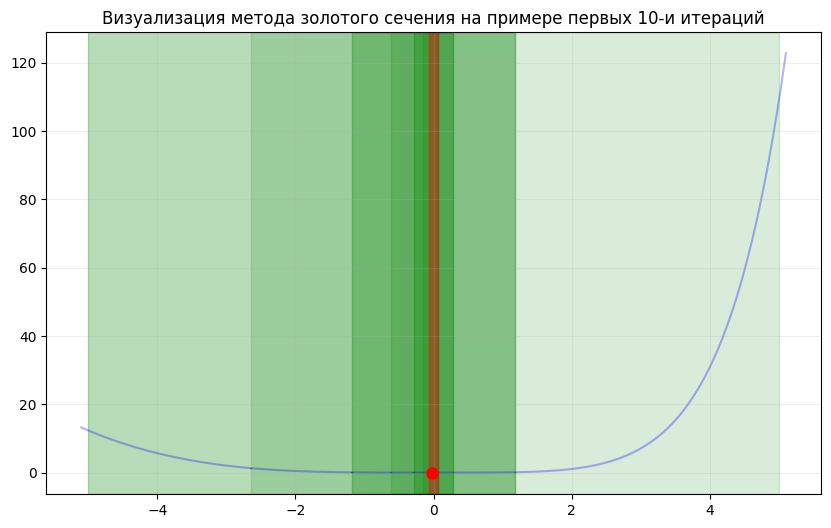

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_range, f_teylor(x_range), 'b', alpha=0.3, label='f_teylor(x)')
ax.set_title("Визуализация метода золотого сечения на примере первых 10-и итераций")

phi = (1 + 5**0.5) / 2
a_g, b_g = -5, 5

for i in range(10):
    x1 = b_g - (b_g - a_g) / phi
    x2 = a_g + (b_g - a_g) / phi
    current_color = 'green' if i < 9 else 'red'
    current_alpha = 0.15 if i < 9 else 0.4
    ax.axvspan(a_g, b_g, color=current_color, alpha=current_alpha)  
    ax.vlines(x1, f_teylor(x1)-0.2, f_teylor(x1)+0.2,
          colors=current_color, linestyles='dotted', alpha=0.7)

    ax.vlines(x2, f_teylor(x2)-0.2, f_teylor(x2)+0.2,
          colors=current_color, linestyles='dotted', alpha=0.7)
    if f_teylor(x1) < f_teylor(x2):
        b_g = x2
    else:
        a_g = x1
x_final = (a_g + b_g) / 2
ax.plot(x_final, f_teylor(x_final), 'ro', markersize=8)


ax.grid(True, alpha=0.2)
plt.show()

### 5.3 Метод ломанных

In [24]:
L_const = 9
x_min_bl, y_min_bl, iterations = broken_line_method(f_teylor, -5, 0, L=L_const, eps=1e-4)
print(f"Метод ломаных:     x = {x_min_bl:.6f}, f(x) = {y_min_bl:.6f}")
print(f"Количество итераций: {iterations}")

Метод ломаных:     x = -0.000081, f(x) = -0.000000
Количество итераций: 19634


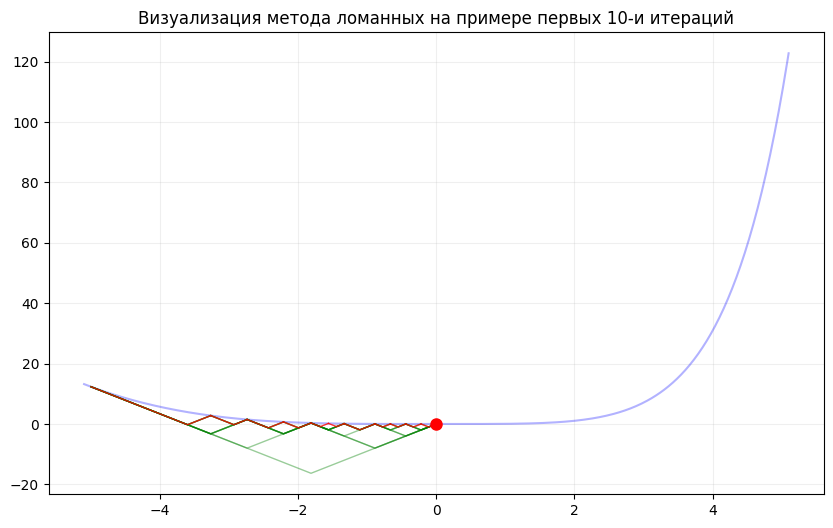

In [19]:
history = history[:11]

x_range = np.linspace(-5 - 0.1, 5 + 0.1, 500)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_range, f_teylor(x_range), 'b', alpha=0.3)

for idx, (hx, hf) in enumerate(history):
    current_color = 'green' if idx < 10 else 'red'
    current_alpha = 0.4 if idx < 10 else 0.8
    
    for j in range(len(hx) - 1):
        x_l, x_r = hx[j], hx[j+1]
        f_l, f_r = hf[j], hf[j+1]
        px = (f_l - f_r + L_const * (x_l + x_r)) / (2 * L_const)
        pf = (f_l + f_r + L_const * (x_l - x_r)) / 2
        ax.plot([x_l, px, x_r], [f_l, pf, f_r], color=current_color, alpha=current_alpha, linewidth=1)

ax.plot(x_min_bl, y_min_bl, 'ro', markersize=8)
ax.set_title("Визуализация метода ломанных на примере первых 10-и итераций")
ax.grid(True, alpha=0.2)
plt.show()

| Метод | x_min| f(x_min) | Кол-во итераций |
| :--- | :--- | :--- | :--- |
| Пакетный scipy | -0.000028 | -0.000000 | - |
| Поразрядного поиска | -0.000064 | 0.000000 | 46 (p = q = 5)|
| Золотого сечения | -0.000126 | 0.000000 | 38 |
| Ломанных | -0.000081 | -0.000000 | 19634 (L = 9) |

## 6. Вывод

В ходе работы были реализованы методы поиска локального минимума на отрезках для двух функций. Метод поразрядного поиска сходится быстрее всех при правильном подборе гиперпараметров (23 итерации и 28 итераций на пологой функции), но данный метод возвращает менее точный результат. Метод ломанных возвращает результат близкий к пакетному методу, но требует значительно больше итераций. Метод золотого сечения менее точный чем метод ломанных, но сзодится за меньше количество итераций, а на первой функции вернул результат такой же как и метод ломанных.